In [ ]:
import pandas as pd
import os
from bs4 import BeautifulSoup


## 1. Load the exported dataset

In [14]:
input_path = "C:/Users/srinithya/Desktop/CR_Github_Self/Projects/CDM/04_hospital_safety_metrics/cms_hospital_safety_export.xlsx"

# Assign the read data to the variable 'df'
df = pd.read_excel(input_path, sheet_name=0)

print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 220 rows, 14 columns


,facility_id,facility_name,state,hospital_type,hospital_ownership,overall_rating,safety_group_measure_count,safety_measures_better,safety_measures_no_different,safety_measures_worse,readm_measures_worse,pct_measures_worse,variance_vs_state_baseline,ownership_risk_rank
0,H100121,Grace County Hospital - AL,AL,Acute Care Hospitals,Voluntary non-profit - Private,4,9,0,9,0,2,0.0000,0.0000,28
1,H100144,Springdale University Medical Center - AL,AL,Acute Care Hospitals,Proprietary,4,9,5,4,0,0,0.0000,0.0000,24
2,H100154,Trinity Health System Hospital - AL,AL,Critical Access Hospitals,Voluntary non-profit - Private,0,11,10,1,0,2,0.0000,0.0000,28
3,H100076,Eastfield General Hospital - AZ,AZ,Critical Access Hospitals,Government - Local,1,9,0,6,3,3,0.3333,0.1391,1
4,H100131,Fairview Health System Hospital - AZ,AZ,Critical Access Hospitals,Government - Hospital District or Authority,3,8,2,4,2,2,0.2500,0.0558,8


## 2. Data cleaning & handling of missing / unrated hospitals

In [15]:
# Normalize column names defensively in case Excel export altered casing/spacing
df.columns = [c.strip().lower() for c in df.columns]

# Track data quality up front
n_missing_rating = df["overall_rating"].isna().sum()
pct_missing_rating = n_missing_rating / len(df) * 100
print(f"Unrated hospitals: {n_missing_rating} ({pct_missing_rating:.1f}% of dataset)")

# Create an explicit categorical flag instead of imputing a numeric rating
df["rating_status"] = np.where(df["overall_rating"].isna(), "Unrated", "Rated")



Unrated hospitals: 0 (0.0% of dataset)


In [16]:
# Safety-measure count fields should never be null after a clean INNER JOIN,
# but we defensively coerce and fill just in case of export artifacts.
count_cols = [
    "safety_group_measure_count",
    "safety_measures_better",
    "safety_measures_no_different",
    "safety_measures_worse",
    "readm_measures_worse",
]
for col in count_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["safety_group_measure_count"] = df["safety_group_measure_count"].replace(0, np.nan)

## 3. Composite Risk Penalty Index

In [17]:
SAFETY_WEIGHT = 1.5
READMISSION_WEIGHT = 1.0

df["weighted_worse_score"] = (
    df["safety_measures_worse"] * SAFETY_WEIGHT
    + df["readm_measures_worse"] * READMISSION_WEIGHT
)

df["composite_risk_penalty_index"] = (
    df["weighted_worse_score"] / df["safety_group_measure_count"] * 100
).round(2)

# Facilities with no valid measure count get an explicit NaN, not a
# misleading 0 (a 0 would imply "confirmed safe" rather than "unknown")
df["composite_risk_penalty_index"] = df["composite_risk_penalty_index"].where(
    df["safety_group_measure_count"].notna()
)

print("Composite Risk Penalty Index summary statistics:")
df["composite_risk_penalty_index"].describe()


Composite Risk Penalty Index summary statistics:


count    220.000000
mean      34.157636
std       22.518671
min        0.000000
25%       16.670000
50%       30.000000
75%       50.000000
max      100.000000
Name: composite_risk_penalty_index, dtype: float64

## 4. Segment outliers by State and Hospital Ownership
We isolate poor performers using a standard IQR-based outlier rule on the Composite Risk Penalty Index, then aggregate to see where risk concentrates structurally (which states, which ownership models).

In [18]:
valid = df.dropna(subset=["composite_risk_penalty_index"]).copy()

q1 = valid["composite_risk_penalty_index"].quantile(0.25)
q3 = valid["composite_risk_penalty_index"].quantile(0.75)
iqr = q3 - q1
outlier_threshold = q3 + 1.5 * iqr

valid["is_outlier"] = valid["composite_risk_penalty_index"] > outlier_threshold
outliers = valid[valid["is_outlier"]]

print(f"Outlier threshold (Q3 + 1.5*IQR): {outlier_threshold:.2f}")
print(f"Flagged {len(outliers)} outlier facilities out of {len(valid)} rated/measured facilities")

Outlier threshold (Q3 + 1.5*IQR): 100.00
Flagged 2 outlier facilities out of 220 rated/measured facilities


In [ ]:
# Aggregate mean risk index and outlier counts by State
state_summary = (
    valid.groupby("state")
    .agg(
        avg_risk_index=("composite_risk_penalty_index", "mean"),
        facility_count=("facility_id", "count"),
        outlier_count=("is_outlier", "sum"),
    ).round(2)
    .sort_values("avg_risk_index", ascending=False)
)
print("Top 10 states by average Composite Risk Penalty Index:")
state_summary.head(10)

Top 10 states by average Composite Risk Penalty Index:


,avg_risk_index,facility_count,outlier_count
state,,,
CA,51.59,7,1
CO,44.43,8,0
TX,43.34,14,1
AZ,42.62,12,0
MO,39.51,12,0
GA,38.08,11,0
WI,34.71,17,0
WA,34.50,12,0
PA,33.21,15,0


In [20]:
# Aggregate mean risk index and outlier counts by Hospital Ownership
ownership_summary = (
    valid.groupby("hospital_ownership")
    .agg(
        avg_risk_index=("composite_risk_penalty_index", "mean"),
        facility_count=("facility_id", "count"),
        outlier_count=("is_outlier", "sum"),
    )
    .round(2)
    .sort_values("avg_risk_index", ascending=False)
)
print("Hospital Ownership models ranked by average Composite Risk Penalty Index:")
ownership_summary

Hospital Ownership models ranked by average Composite Risk Penalty Index:


,avg_risk_index,facility_count,outlier_count
hospital_ownership,,,
Government - Hospital District or Authority,38.42,36,0
Government - State,36.54,12,0
Voluntary non-profit - Church,35.52,10,0
Government - Local,35.30,23,0
Physician,34.73,26,0
Voluntary non-profit - Other,33.95,15,0
Voluntary non-profit - Private,33.12,68,2
Proprietary,29.17,27,0
Government - Federal,24.69,3,0


## 5. Visualization: Ownership vs. Risk Penalty (Seaborn boxplot)

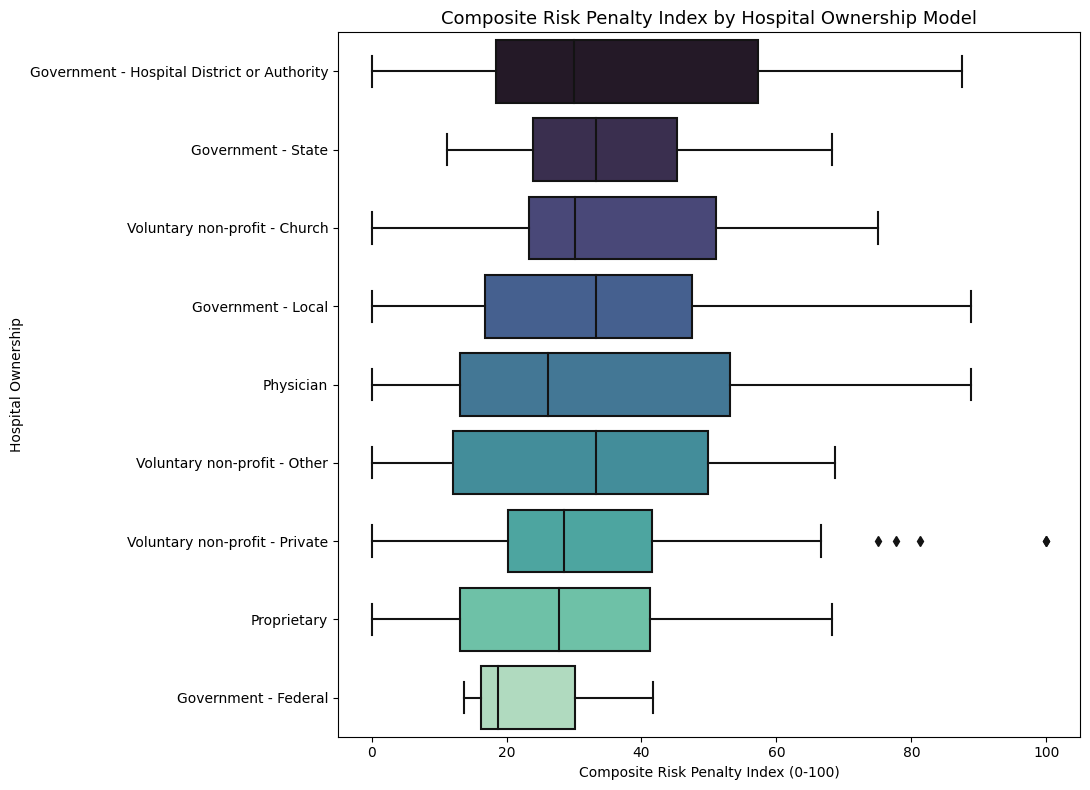

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(11, 8))
order = ownership_summary.index.tolist()

ax = sns.boxplot(
    data=valid,
    x="composite_risk_penalty_index",
    y="hospital_ownership",
    order=order,
    palette="mako",
)
ax.set_title("Composite Risk Penalty Index by Hospital Ownership Model", fontsize=13)
ax.set_xlabel("Composite Risk Penalty Index (0-100)")
ax.set_ylabel("Hospital Ownership")
plt.tight_layout()
plt.show()

### **Interpretation**
Based on the generated plot, Government - Hospital District or Authority shows the highest median composite risk penalty index, while Government - Federal exhibits the lowest.

### **Key Visual Insights**

* Highest Risks: "Government - Hospital District or Authority" has a broad risk distribution and a median score near 33, making its overall risk exposure noticeably higher than other models.
* Lowest Risks: "Government - Federal" is highly compact with a median score around 19, demonstrating tight control and the lowest risk index.
* Statistical Outliers: Only the Voluntary non-profit - Private group displays extreme statistical outliers, with several hospitals plotting far to the right, including one maxing out at 100.


## 6. Visualization: Overall Rating distribution

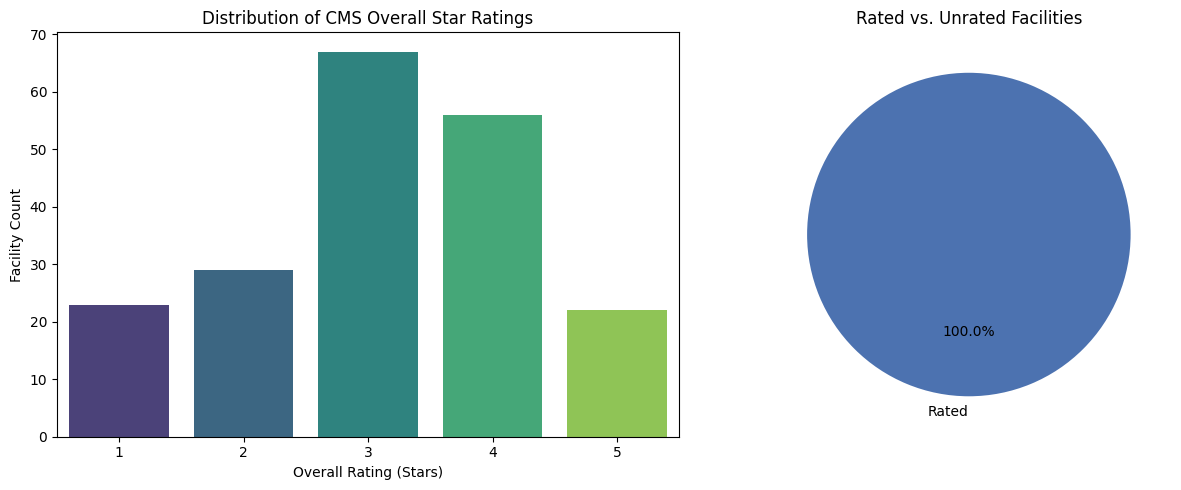

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(
    data=df[df["rating_status"] == "Rated"],
    x="overall_rating",
    order=[1, 2, 3, 4, 5],
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Distribution of CMS Overall Star Ratings")
axes[0].set_xlabel("Overall Rating (Stars)")
axes[0].set_ylabel("Facility Count")

rating_status_counts = df["rating_status"].value_counts()
axes[1].pie(
    rating_status_counts,
    labels=rating_status_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C72B0", "#DD8452"],
)
axes[1].set_title("Rated vs. Unrated Facilities")

plt.tight_layout()
plt.show()

### **Interpretation**
Based on plots, 3-star facilities represent the largest group in dataset, while pie chart reveals that filtering or data cleaning step left exactly 100% rated facilities with no missing data.

### **Key Visual Insights**

* Bell-Shaped Distribution: The CMS Star Ratings show a slightly right-skewed, normal-like distribution centered cleanly on 3 stars (~67 facilities) and 4 stars (~56 facilities).
* Extreme Tiers: Lowest-performing 1-star facilities (~23) slightly outnumber the highest-performing 5-star facilities (~22).
* Redundant Visualization: The "Rated vs. Unrated Facilities" pie chart shows a single solid block at 100.0%. Since there are zero unrated facilities remaining, this visualization doesn't offer useful variance for a dashboard or report.


## 7. Export outlier facilities for stakeholder follow-up

In [25]:
outlier_worklist = (
    outliers[
        [
            "facility_id",
            "facility_name",
            "state",
            "hospital_ownership",
            "overall_rating",
            "composite_risk_penalty_index",
        ]
    ]
    .sort_values("composite_risk_penalty_index", ascending=False)
    .reset_index(drop=True)
)

print(f"Exporting {len(outlier_worklist)} high-risk facilities to outlier_worklist.xlsx")
outlier_worklist.to_excel("outlier_worklist.xlsx", index=False)

outlier_worklist.head(10)

Exporting 2 high-risk facilities to outlier_worklist.xlsx


,facility_id,facility_name,state,hospital_ownership,overall_rating,composite_risk_penalty_index
0,H100089,Southport University Medical Center - CA,CA,Voluntary non-profit - Private,1,100.0
1,H100040,Westbrook Health System Hospital - TX,TX,Voluntary non-profit - Private,2,100.0


## 8. Summary
* Loaded and cleaned the CMS-modeled export with explicit, non-fabricating handling of unrated facilities (`rating_status` flag rather than imputed values).
* Engineered a weighted **Composite Risk Penalty Index** blending patient-safety and readmission "worse-than-national" measures.
* Segmented outliers via IQR and aggregated risk by **State** and **Hospital Ownership** to surface structural patterns.
* Produced two presentation-ready plots (ownership boxplot, rating distribution) and exported a prioritized outlier worklist for downstream BI reporting. 
* Generated optimized Seaborn distribution plots mapping ownership boxplots and rating histograms for internal data review.
* Generated a prioritized, machine-readable worklist (outlier_worklist.xlsx) to route directly to clinical audit teams for localized, targeted remediation.